# Healthcare Cost Prediction: Regularized Regression vs. MLP
## tl;dr
On one fixed held-out split, a small two-hidden-layer MLP had mean **RMSE 4,520.6**, versus **5,957.9** for ordinary Ridge: **24.1% lower RMSE**. Adding prespecified nonlinear/interaction features to Ridge reduced its RMSE to **4,547.2**, leaving just **0.6%** difference from the MLP mean.

These are regression error comparisons, not classification accuracy percentages. The MLP was repeated with five seeds; RMSE SD was **55.9**. This measures initialization/training variability on the same split, not uncertainty over new populations. The 26.6-unit gap from engineered Ridge is small and does not establish a reliable winner.

An input-gradient calculation also confirms that the MLP permits local BMI sensitivity analysis. This is a property of fitted predictions, not a causal medical effect.

## Context & Methods
**Question:** Does a neural network improve cost predictions compared with L1/L2 regression, and can we explain its sensitivity to BMI?

- Data: the common public `insurance.csv`, six predictors and target `charges`. The downloaded file is bundled so rerunning needs no dataset download. This is a fresh benchmark, not a reproduction of the user's unavailable original code or a verified copy of their old file.
- Drop one fully identical row before splitting: 1,338 original records → 1,337 unique rows.
- Fixed 80/20 random split, seed 42: **1,069 training** and **268 test** rows. No time/patient identifiers exist to support temporal or patient-level validation.
- Identical five shuffled CV folds on training data for all four models; selection by CV RMSE only. Test data is opened only after tuning.
- Numeric predictors are standardized; categorical predictors one-hot encoded. Each transform is fitted within the training fold. The target is also standardized within each training fold and predictions inverse-transformed to original `charges` units.
- Ridge and Lasso with original inputs are the direct comparison with MLP. Engineered Ridge adds **BMI²** and **smoker × BMI**, declared before evaluating test scores; it is an additional feature-engineering benchmark, not an identical-input comparison.
- MLP: hidden layers **32 → 16**, ReLU, Adam, squared-error loss, L2 penalty and early stopping; learning rates 0.0003 / 0.001 / 0.003 and L2 alpha 0.0001 / 0.01. Five independent fits after selecting settings: seeds 42–46. Do not select the best seed using test scores.
- No dropout or gradient clipping was used. `scikit-learn` MLP is sufficient for this first comparison; a later PyTorch ablation can test dropout.

### Key Assumptions
Rows are treated as independent observations. Dataset representativeness, clinical provenance, patient overlap and currency are not verified. Cost metrics therefore use **original charges units**. This educational benchmark cannot establish clinical effectiveness or an operational insurance-pricing policy.

Early stopping reserves 15% internally from each training fold. The enclosing transforms are fitted to that full training fold, including its internal early-stop subset; **the outer CV validation and held-out test data remain excluded**. A stricter future study can also fit transforms only on the inner fitting subset.

### Sources and environment
- [Kaggle reference: Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance)
- [Actual downloaded CSV](https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv)
- [Dataset repository](https://github.com/stedy/Machine-Learning-with-R-datasets)
- [StandardScaler documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [MLPRegressor documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)

Downloaded 2026-10-08. SHA-256: `505c1cbc2e63d0363bac59501563df2530aadf4cdb9cfee226f4ef32f5468281`.

Extract this package, install `requirements.txt`, open the notebook in Jupyter or VS Code and **Run All**. A complete executed HTML copy is also included. No PyTorch or external service is required. Exact package versions appear below; floating-point results can vary slightly across platforms.

In [1]:
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
from IPython.display import display
import hashlib, io, json, os, platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning


print({'python': platform.python_version(), 'scikit-learn': sklearn.__version__,
       'numpy': np.__version__, 'pandas': pd.__version__})

{'python': '3.12.14', 'scikit-learn': '1.8.0', 'numpy': '2.3.5', 'pandas': '2.2.3'}


## Data
### 1. Load and check the bundled data
Keep the original row index for traceable predictions. There are no missing values. Exact duplicate removal does not establish that all remaining rows represent different people.

In [2]:
DATA_BYTES = Path('insurance.csv').read_bytes()
raw = pd.read_csv(io.BytesIO(DATA_BYTES))
df = raw.drop_duplicates().copy()
X, y = df.drop(columns='charges'), df.charges
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
assert set(X_train.index).isdisjoint(X_test.index)
assert not df.isna().any().any()
CV = list(KFold(n_splits=5, shuffle=True, random_state=42).split(X_train))
SEEDS = [42, 43, 44, 45, 46]


print({'original_rows': len(raw), 'duplicates_removed': len(raw)-len(df),
       'missing_cells': int(raw.isna().sum().sum()), 'train': len(X_train), 'test': len(X_test)})
display(df.head())

{'original_rows': 1338, 'duplicates_removed': 1, 'missing_cells': 0, 'train': 1069, 'test': 268}


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 2. Define models and preprocessing
Standardization changes location and scale, not distribution shape. It is distinct from L1/L2 regularization. The target stays on a squared-error scale; no logarithm is used. Ridge/Lasso alpha values are tuned on this standardized target and should not be compared numerically with alpha values from unscaled-target fits.

In [3]:
def engineer_features(frame):
    # Prespecified functional forms, not selected using held-out test results.
    out = frame.copy()
    out['bmi_squared'] = out.bmi ** 2
    out['smoker_bmi'] = out.bmi * (out.smoker == 'yes').astype(float)
    return out

def make_model(estimator, engineered=False):
    numeric = ['age', 'bmi', 'children']
    if engineered:
        numeric += ['bmi_squared', 'smoker_bmi']
    pre = ColumnTransformer([
        ('numeric', StandardScaler(), numeric),
        ('category', OneHotEncoder(drop='first', handle_unknown='ignore',
                                   sparse_output=False), ['sex', 'smoker', 'region'])
    ], verbose_feature_names_out=False)
    steps = []
    if engineered:
        steps.append(('features', FunctionTransformer(engineer_features, validate=False)))
    steps += [('preprocess', pre), ('model', estimator)]
    # Scaling y is useful for Adam. It does NOT log-transform y or change the
    # objective from squared error on charges; inverse transform restores units.
    return TransformedTargetRegressor(regressor=Pipeline(steps), transformer=StandardScaler())

def metrics(actual, predicted):
    return dict(RMSE=float(root_mean_squared_error(actual, predicted)),
                MAE=float(mean_absolute_error(actual, predicted)),
                R2=float(r2_score(actual, predicted)))



### 3. Tune on training-only CV
All candidate configurations and folds are fixed before test evaluation. CV fold SD describes variation among these folds, not a confidence interval. No further tuning should be motivated by the test results below.

In [4]:
specs = {
    'Ridge (L2)': (make_model(Ridge()),
        {'regressor__model__alpha': [0.01, 0.1, 1, 10, 100]}),
    'Lasso (L1)': (make_model(Lasso(max_iter=10000)),
        {'regressor__model__alpha': [0.0001, 0.001, 0.01, 0.1]}),
    'Ridge + engineered features': (make_model(Ridge(), engineered=True),
        {'regressor__model__alpha': [0.01, 0.1, 1, 10, 100]}),
    'MLP (32, 16)': (make_model(MLPRegressor(
        hidden_layer_sizes=(32, 16), activation='relu', solver='adam',
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=40, max_iter=1500, tol=1e-5,
        batch_size=64, random_state=42)),
        {'regressor__model__learning_rate_init': [0.0003, 0.001, 0.003],
         'regressor__model__alpha': [0.0001, 0.01]})
}
searches, tuning_records = {}, []
for name, (model, grid) in specs.items():
    print('Tuning:', name, flush=True)
    search = GridSearchCV(model, grid, cv=CV, scoring='neg_root_mean_squared_error',
                          n_jobs=1, refit=True, error_score='raise')
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        search.fit(X_train, y_train)
    searches[name] = search
    print('CV RMSE:', round(-search.best_score_, 2), search.best_params_, flush=True)
    for i, p in enumerate(search.cv_results_['params']):
        tuning_records.append(dict(model=name, parameters=json.dumps(p),
            CV_RMSE=-float(search.cv_results_['mean_test_score'][i]),
            CV_fold_SD=float(search.cv_results_['std_test_score'][i])))
    if caught:
        print('Warnings:', sorted(set(str(w.message) for w in caught)), flush=True)



Tuning: Ridge (L2)
CV RMSE: 6123.64 {'regressor__model__alpha': 0.1}
Tuning: Lasso (L1)
CV RMSE: 6121.62 {'regressor__model__alpha': 0.001}
Tuning: Ridge + engineered features
CV RMSE: 4925.73 {'regressor__model__alpha': 0.1}
Tuning: MLP (32, 16)
CV RMSE: 4993.31 {'regressor__model__alpha': 0.0001, 'regressor__model__learning_rate_init': 0.003}


In [5]:
tuning = pd.DataFrame(tuning_records)
display(tuning[tuning.model == 'MLP (32, 16)'].sort_values('CV_RMSE').round(2))

,model,parameters,CV_RMSE,CV_fold_SD
16,"MLP (32, 16)","{""regressor__model__alpha"": 0.0001, ""regressor...",4993.31,138.69
19,"MLP (32, 16)","{""regressor__model__alpha"": 0.01, ""regressor__...",4996.09,140.86
14,"MLP (32, 16)","{""regressor__model__alpha"": 0.0001, ""regressor...",5013.57,204.53
17,"MLP (32, 16)","{""regressor__model__alpha"": 0.01, ""regressor__...",5018.61,201.40
18,"MLP (32, 16)","{""regressor__model__alpha"": 0.01, ""regressor__...",5028.93,134.15
15,"MLP (32, 16)","{""regressor__model__alpha"": 0.0001, ""regressor...",5043.33,128.57


## Results
### 4. Evaluate the held-out test set and repeat MLP training
Scores for MLP are **means of five separate model scores**, not scores of an averaged-prediction ensemble. The three deterministic regression baselines are fitted once. Tail MAE uses a threshold fixed from the training target's 90th percentile, not a test-derived percentile.

In [6]:
# All tuning is now finished. Only now evaluate held-out observations.
predictions = pd.DataFrame({'original_row_id': X_test.index, 'actual_charges': y_test.values})
score_records = []
models = {}
threshold = float(y_train.quantile(0.9))
tail = y_test.to_numpy() >= threshold
for name in ['Ridge (L2)', 'Lasso (L1)', 'Ridge + engineered features']:
    model = searches[name].best_estimator_
    pred = model.predict(X_test)
    models[name] = model
    predictions[name] = pred
    score_records.append(dict(model=name, seed=None, **metrics(y_test, pred),
        tail_MAE=float(mean_absolute_error(y_test.to_numpy()[tail], pred[tail])),
        negative_predictions=int((pred < 0).sum()), epochs=None))
for seed in SEEDS:
    model = clone(searches['MLP (32, 16)'].best_estimator_)
    model.set_params(regressor__model__random_state=seed)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    models[f'MLP seed {seed}'] = model
    predictions[f'MLP seed {seed}'] = pred
    score_records.append(dict(model='MLP (32, 16)', seed=seed, **metrics(y_test, pred),
        tail_MAE=float(mean_absolute_error(y_test.to_numpy()[tail], pred[tail])),
        negative_predictions=int((pred < 0).sum()),
        epochs=int(model.regressor_.named_steps['model'].n_iter_)))
scores = pd.DataFrame(score_records)
summary = scores.groupby('model', sort=False).agg(
    RMSE=('RMSE', 'mean'), RMSE_seed_SD=('RMSE', 'std'),
    MAE=('MAE', 'mean'), MAE_seed_SD=('MAE', 'std'), R2=('R2', 'mean'),
    R2_seed_SD=('R2', 'std'), tail_MAE=('tail_MAE', 'mean'))
summary[['RMSE_seed_SD','MAE_seed_SD','R2_seed_SD']] = summary[
    ['RMSE_seed_SD','MAE_seed_SD','R2_seed_SD']].fillna(0)

mlp_rmse = summary.loc['MLP (32, 16)', 'RMSE']
improvements = {name: 100 * (summary.loc[name, 'RMSE'] - mlp_rmse) /
                         summary.loc[name, 'RMSE'] for name in summary.index if name != 'MLP (32, 16)'}



In [7]:
display(summary.round(3))
display(scores.round(3))
print('Training 90th-percentile threshold:', round(threshold, 2), '; test rows above it:', int(tail.sum()))
print('RMSE reduction vs baseline (%):', {k: round(v, 3) for k,v in improvements.items()})

Training 90th-percentile threshold: 33902.03 ; test rows above it: 38
RMSE reduction vs baseline (%): {'Ridge (L2)': np.float64(24.124), 'Lasso (L1)': np.float64(24.304), 'Ridge + engineered features': np.float64(0.585)}


,RMSE,RMSE_seed_SD,MAE,MAE_seed_SD,R2,R2_seed_SD,tail_MAE
model,,,,,,,
Ridge (L2),5957.879,0.000,4178.739,0.000,0.807,0.000,9265.329
Lasso (L1),5971.994,0.000,4185.633,0.000,0.806,0.000,9333.357
Ridge + engineered features,4547.198,0.000,2821.073,0.000,0.887,0.000,4469.182
"MLP (32, 16)",4520.580,55.944,2764.376,93.827,0.889,0.003,3771.604


,model,seed,RMSE,MAE,R2,tail_MAE,negative_predictions,epochs
0,Ridge (L2),NaN,5957.879,4178.739,0.807,9265.329,1,NaN
1,Lasso (L1),NaN,5971.994,4185.633,0.806,9333.357,2,NaN
2,Ridge + engineered features,NaN,4547.198,2821.073,0.887,4469.182,0,NaN
3,"MLP (32, 16)",42.0,4546.197,2701.532,0.888,4141.450,0,62.0
4,"MLP (32, 16)",43.0,4568.345,2653.864,0.886,4012.160,0,61.0
5,"MLP (32, 16)",44.0,4445.648,2894.124,0.892,3647.282,0,66.0
6,"MLP (32, 16)",45.0,4565.882,2811.343,0.887,3491.357,1,108.0
7,"MLP (32, 16)",46.0,4476.831,2761.019,0.891,3565.773,0,80.0


**Read the numbers:** RMSE and MAE are lower-is-better, R² is higher-is-better.

**RMSE reduction (%) = 100 × (baseline RMSE − mean MLP RMSE) / baseline RMSE.**

MLP improves substantially over raw linear inputs. The engineered Ridge benchmark is much closer. None of this implies MLP is universally more accurate or more robust to outliers.

### 5. Compare errors visually
Horizontal bars start at zero. The MLP whisker is ± one sample SD across five seeds; it is **not** a 95% confidence interval. Regression baselines have no repeated-seed SD.

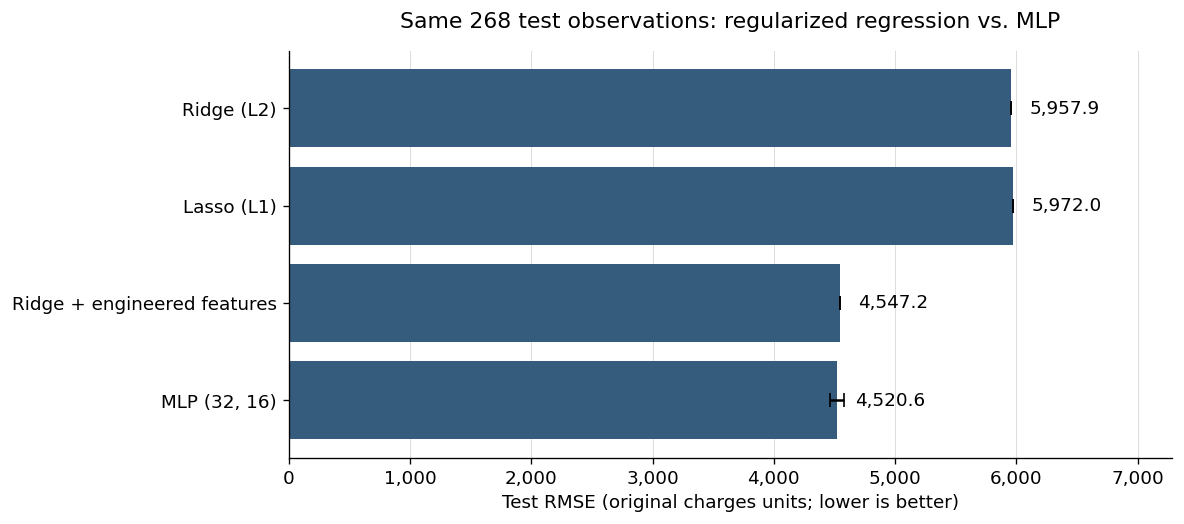

In [8]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
plt.rcParams.update({'figure.figsize': (9, 4.5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlepad': 14, 'figure.dpi': 120})
order = ['Ridge (L2)', 'Lasso (L1)', 'Ridge + engineered features', 'MLP (32, 16)']
values = summary.loc[order, 'RMSE'].to_numpy()
spread = summary.loc[order, 'RMSE_seed_SD'].to_numpy()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(order, values, color='#355C7D', xerr=spread, capsize=4)
ax.invert_yaxis()
ax.set_xlim(0, max(values)*1.22)
for i,v in enumerate(values):
    ax.text(v+max(values)*0.025, i, f'{v:,.1f}', va='center')
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Test RMSE (original charges units; lower is better)')
ax.set_title('Same 268 test observations: regularized regression vs. MLP')
ax.grid(axis='x', color='#dddddd', linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### 6. Inspect individual predictions
The ideal line is predicted = observed. This plots all test records, including high-cost cases; it does not select only examples where a model performs well. MLP seed 42 is a prespecified illustrative run, distinct from the mean metrics above.

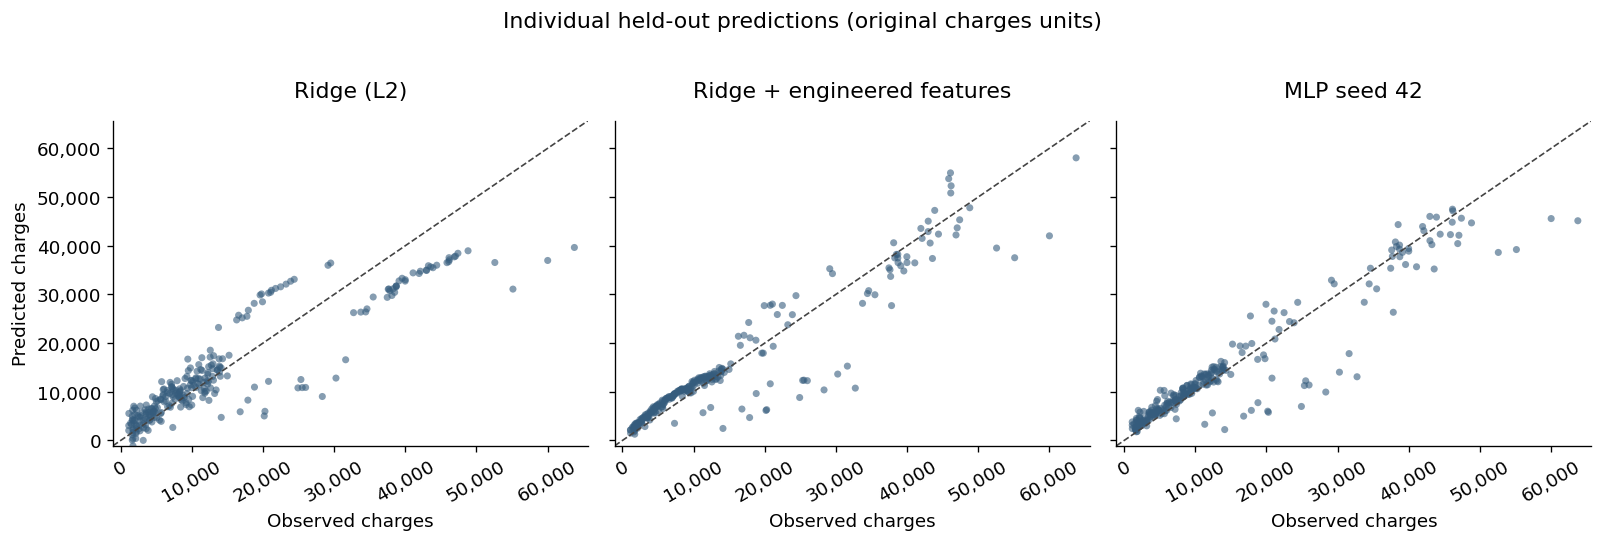

In [9]:
plot_models = ['Ridge (L2)', 'Ridge + engineered features', 'MLP seed 42']
lo = min(0, predictions[plot_models].to_numpy().min())
hi = max(predictions.actual_charges.max(), predictions[plot_models].to_numpy().max()) * 1.03
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharex=True, sharey=True)
for ax, name in zip(axes, plot_models):
    ax.scatter(predictions.actual_charges, predictions[name], s=18, alpha=0.6,
               color='#355C7D', edgecolors='none')
    ax.plot([lo, hi], [lo, hi], '--', color='#444444', linewidth=1)
    ax.set(xlim=(lo,hi), ylim=(lo,hi), title=name,
           xlabel='Observed charges')
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Predicted charges')
fig.suptitle('Individual held-out predictions (original charges units)', y=1.02)
fig.tight_layout()
plt.show()

### 7. Check local BMI sensitivity with the chain rule
Use a fixed profile: age 40, female, BMI 30, one child, southwest; compare smoker/no smoker. Hold other recorded variables constant.

- **Local derivative**: `∂fθ(x)/∂BMI` at BMI 30, in charges per BMI unit.
- **Finite change**: `fθ(BMI+1, …) − fθ(BMI, …)`.
- For MLP, explicitly apply the chain rule through fitted ReLU layers and account for input and target scaling. Check against a central finite difference with `ε = 10⁻⁵`.

These two quantities can differ because a full BMI-unit change is not infinitesimal and can cross ReLU boundaries. Training backpropagation of the **loss with respect to weights** and prediction differentiation **with respect to BMI** use the chain rule for different derivatives. They are not interchangeable.

A negative non-smoker gradient in this fitted MLP is a useful caution: mathematical sensitivity describes the model's local behavior and is not a biological conclusion. Correlated variables and unsupported combinations may also make fixed-input perturbations unrealistic.

In [10]:
# Inspect a defined profile, NOT a test case chosen to flatter a model.
# This is sensitivity of predictions, not causal effects or clinical evidence.
profiles = pd.DataFrame([
    dict(age=40, sex='female', bmi=30., children=1, smoker=s, region='southwest')
    for s in ['no', 'yes']])
plus = profiles.copy(); plus['bmi'] += 1
eps = 1e-5
tiny_plus = profiles.copy(); tiny_plus['bmi'] += eps
tiny_minus = profiles.copy(); tiny_minus['bmi'] -= eps

def mlp_bmi_input_gradient(fitted, profile):
    """Chain rule through frozen ReLU network; units: charges / raw BMI unit."""
    pipe = fitted.regressor_
    pre = pipe.named_steps['preprocess']
    nn = pipe.named_steps['model']
    z = pre.transform(profile)
    activations = [z]
    gates = []
    for weights, bias in zip(nn.coefs_[:-1], nn.intercepts_[:-1]):
        h = activations[-1] @ weights + bias
        gates.append((h > 0).astype(float))
        activations.append(np.maximum(h, 0))
    grad = np.tile(nn.coefs_[-1].T, (len(profile), 1))
    for k in range(len(gates)-1, -1, -1):
        grad = (grad * gates[k]) @ nn.coefs_[k].T
    bmi_index = list(pre.get_feature_names_out()).index('bmi')
    x_scale = pre.named_transformers_['numeric'].scale_[1]
    y_scale = fitted.transformer_.scale_[0]
    return grad[:, bmi_index] * y_scale / x_scale

sensitivity_records = []
for name in ['Ridge (L2)', 'Ridge + engineered features', 'MLP seed 42']:
    model = models[name]
    base_pred, step_pred = model.predict(profiles), model.predict(plus)
    derivative = (model.predict(tiny_plus) - model.predict(tiny_minus)) / (2*eps)
    if name == 'MLP seed 42':
        chain = mlp_bmi_input_gradient(model, profiles)
        assert np.allclose(chain, derivative, rtol=1e-5, atol=0.01)
    else:
        chain = [None, None]
    for i, row in profiles.iterrows():
        sensitivity_records.append(dict(model=name, smoker=row.smoker, bmi=30,
            prediction=float(base_pred[i]), BMI_plus_1=float(step_pred[i]-base_pred[i]),
            local_BMI_gradient=float(derivative[i]), chain_rule_gradient=chain[i]))
sensitivity = pd.DataFrame(sensitivity_records)



In [11]:
display(sensitivity.round(3))

,model,smoker,bmi,prediction,BMI_plus_1,local_BMI_gradient,chain_rule_gradient
0,Ridge (L2),no,30,8272.860,318.624,318.624,NaN
1,Ridge (L2),yes,30,31336.854,318.624,318.624,NaN
2,Ridge + engineered features,no,30,8825.123,32.252,40.899,NaN
3,Ridge + engineered features,yes,30,31452.165,1491.113,1499.760,NaN
4,MLP seed 42,no,30,6982.406,-221.353,-221.353,-221.353
5,MLP seed 42,yes,30,33630.938,2495.447,2434.544,2434.544


## Checks
Recalculate every MAE/RMSE directly from saved prediction vectors. Check input-gradient agreement and disjoint test indices. These checks validate computations, not real-world medical or causal validity.

In [12]:
# Independent recalculation from saved prediction vectors.
for rec in score_records:
    key = rec['model'] if rec['seed'] is None else f"MLP seed {rec['seed']}"
    errors = predictions[key].to_numpy() - predictions.actual_charges.to_numpy()
    assert np.isclose(np.sqrt(np.mean(errors ** 2)), rec['RMSE'])
    assert np.isclose(np.mean(np.abs(errors)), rec['MAE'])


print('All numerical checks passed; no test overlap and no missing values.')

All numerical checks passed; no test overlap and no missing values.


## Takeaways
- A small MLP can learn nonlinear predictive relationships without manually supplied interaction terms; Ridge can also represent such relationships when features are engineered. In this run, feature engineering explains most of the apparent MLP advantage over ordinary Ridge.
- Standardization and regularization are available to both approaches. Scaling does not make data normally distributed. Both squared-error models can be affected by extreme target values; architecture alone does not prove outlier robustness.
- Input gradients and finite perturbations provide local MLP explanations. Regression coefficients are easier to summarize globally in simple linear specifications, but regularization shrinkage, interactions and correlated predictors limit simplistic interpretations. Neither model establishes causal marginal medical costs.
- Tail MAE is descriptive on a small subgroup (threshold and count printed above). A lower tail error here does not validate all rare/extreme scenarios.
- The selected MLP used Adam learning rate **0.003** and L2 alpha **0.0001**. Do not infer this is the best choice for other data. No dropout or clipping was tested.
- One split cannot establish a stable ranking. Next study: repeated or nested CV on development data, an independently retained evaluation set, a tree-based comparator, and a PyTorch ablation changing **one** item at a time (learning rate, dropout or clipping). Avoid retuning against this already-seen test set.

### Suggested resume wording (only for this completed experiment)
Compared L1/L2-regularized regression with a two-hidden-layer MLP using training-only five-fold cross-validation and a common held-out test set; repeated neural-network training across five seeds and evaluated RMSE, MAE and R². Achieved 24.1% lower test RMSE than ordinary Ridge, while an engineered Ridge benchmark narrowed the gap to 0.6%; examined local BMI sensitivity using input gradients and finite perturbations.

Use **scikit-learn**, Adam, L2 and early stopping for this version. Do not claim PyTorch, dropout, causal marginal effects, deployed risk pricing, or a 24.1% increase in accuracy.